In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of charachers and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [11]:
# build the "lookup table" 'C'
# 27 characters, embedded in a lower dimensional space
C = torch.randn((27, 2))

In [12]:
C

tensor([[-0.0354, -1.4306],
        [-0.9840, -0.8871],
        [ 0.5669,  1.0111],
        [-1.1782, -0.6637],
        [-0.4649, -0.0326],
        [ 0.8625, -0.3241],
        [ 0.8282, -0.4651],
        [-0.4580,  1.2333],
        [-0.6960,  0.9445],
        [ 1.0797, -0.1513],
        [ 1.2807,  0.6004],
        [ 2.4414,  0.1123],
        [ 1.5759, -0.8779],
        [ 1.1060, -1.0243],
        [ 0.5325,  0.5875],
        [-1.7314,  1.7486],
        [ 0.1305,  0.1327],
        [-0.2705,  0.1210],
        [ 0.3005,  0.1520],
        [-0.1576, -1.8266],
        [ 0.1181, -0.8854],
        [ 0.1609,  0.6230],
        [ 0.7933,  0.6770],
        [ 0.0746, -0.6078],
        [ 0.3140,  1.8194],
        [ 0.4549, -2.3318],
        [ 1.1067, -0.7212]])

In [13]:
# 2 ways to think about indexing into C
# initial:

In [14]:
C[5]

tensor([ 0.8625, -0.3241])

In [15]:
# second:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.8625, -0.3241])

In [16]:
# can think of the indexing as a first layer of the neural net
# there is no non-linearity (tanh), weight matrix is C
# encoding integers into one_hot and feeding in
# this 'first layer' embeds them

In [17]:
# different ways of indexing
C[5]

tensor([ 0.8625, -0.3241])

In [18]:
C[[5, 6, 7]]

tensor([[ 0.8625, -0.3241],
        [ 0.8282, -0.4651],
        [-0.4580,  1.2333]])

In [20]:
C[torch.tensor([5, 6, 7, 7, 7])]

tensor([[ 0.8625, -0.3241],
        [ 0.8282, -0.4651],
        [-0.4580,  1.2333],
        [-0.4580,  1.2333],
        [-0.4580,  1.2333]])

In [21]:
# index w/ multidimensional vectors
C[X]

tensor([[[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306]],

        [[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [ 0.8625, -0.3241]],

        [[-0.0354, -1.4306],
         [ 0.8625, -0.3241],
         [ 1.1060, -1.0243]],

        [[ 0.8625, -0.3241],
         [ 1.1060, -1.0243],
         [ 1.1060, -1.0243]],

        [[ 1.1060, -1.0243],
         [ 1.1060, -1.0243],
         [-0.9840, -0.8871]],

        [[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306]],

        [[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-1.7314,  1.7486]],

        [[-0.0354, -1.4306],
         [-1.7314,  1.7486],
         [ 1.5759, -0.8779]],

        [[-1.7314,  1.7486],
         [ 1.5759, -0.8779],
         [ 1.0797, -0.1513]],

        [[ 1.5759, -0.8779],
         [ 1.0797, -0.1513],
         [ 0.7933,  0.6770]],

        [[ 1.0797, -0.1513],
         [ 0.7933,  0.6770],
         [ 1.0797, -0.1513]],

        [[ 0.7933,  0

In [22]:
C[X].shape

torch.Size([32, 3, 2])

In [23]:
X[13,2]

tensor(1)

In [24]:
C[X][13,2]

tensor([-0.9840, -0.8871])

In [25]:
C[1]

tensor([-0.9840, -0.8871])

In [26]:
# in summary pytorch indexing is awesom!

In [60]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [61]:
# construct hidden layer
# weights initialized randomly, 6 dimensions for (3 * 2) from input shape above
# num neurons is up to us, 100 for example
W1 = torch.randn((6, 100))
# biases also initialized randomly
b1 = torch.randn(100)

In [62]:
# need to 'concatenate' inputs in [32, 3, 2] 
# so we can mult by [6, 100]
# as in emb @ W1 + b1

In [63]:
# torch.cat does just that
# this will not generalize if we change block size
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [64]:
# torch.unbind does what we need
# pass in the embedding and specify a dimension
# returns a tuple of slices along a given dimension, already without it
torch.unbind(emb, 1)

(tensor([[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [ 0.8625, -0.3241],
         [ 1.1060, -1.0243],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-1.7314,  1.7486],
         [ 1.5759, -0.8779],
         [ 1.0797, -0.1513],
         [ 0.7933,  0.6770],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.9840, -0.8871],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [ 1.0797, -0.1513],
         [-0.1576, -1.8266],
         [-0.9840, -0.8871],
         [ 0.5669,  1.0111],
         [ 0.8625, -0.3241],
         [ 1.5759, -0.8779],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [-0.1576, -1.8266],
         [-1.7314,  1.7486],
         [ 0.1305,  0.1327],
         [-0.6960,  0.9445]]),
 tensor([[-0.0354, -1.4306],
         [-0.0354, -1.4306],
         [ 0

In [65]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [66]:
# there is still another better way!

In [67]:
# ASIDE>>>
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [68]:
a.shape

torch.Size([18])

In [69]:
a.view(2, 9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [70]:
a.view(9, 2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [71]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [72]:
# tensor always represented in computer memory as 1-dimensional vector
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [73]:
emb.view(32, 6)

tensor([[-0.0354, -1.4306, -0.0354, -1.4306, -0.0354, -1.4306],
        [-0.0354, -1.4306, -0.0354, -1.4306,  0.8625, -0.3241],
        [-0.0354, -1.4306,  0.8625, -0.3241,  1.1060, -1.0243],
        [ 0.8625, -0.3241,  1.1060, -1.0243,  1.1060, -1.0243],
        [ 1.1060, -1.0243,  1.1060, -1.0243, -0.9840, -0.8871],
        [-0.0354, -1.4306, -0.0354, -1.4306, -0.0354, -1.4306],
        [-0.0354, -1.4306, -0.0354, -1.4306, -1.7314,  1.7486],
        [-0.0354, -1.4306, -1.7314,  1.7486,  1.5759, -0.8779],
        [-1.7314,  1.7486,  1.5759, -0.8779,  1.0797, -0.1513],
        [ 1.5759, -0.8779,  1.0797, -0.1513,  0.7933,  0.6770],
        [ 1.0797, -0.1513,  0.7933,  0.6770,  1.0797, -0.1513],
        [ 0.7933,  0.6770,  1.0797, -0.1513, -0.9840, -0.8871],
        [-0.0354, -1.4306, -0.0354, -1.4306, -0.0354, -1.4306],
        [-0.0354, -1.4306, -0.0354, -1.4306, -0.9840, -0.8871],
        [-0.0354, -1.4306, -0.9840, -0.8871,  0.7933,  0.6770],
        [-0.9840, -0.8871,  0.7933,  0.6

In [74]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [75]:
# Finally
# h = emb.view(emb.shape[0], 6) @ W1 + b1
# shape can be inferred if you use '-1' as a placeholder
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [76]:
h

tensor([[ 0.8670,  0.7905, -0.9999,  ..., -0.6082, -0.8087, -0.5777],
        [ 0.9940,  0.4306, -0.9989,  ..., -0.7395, -0.5129,  0.5860],
        [ 0.1689, -0.2333, -1.0000,  ..., -0.9951, -0.9511, -0.6679],
        ...,
        [ 0.6333, -0.9304,  0.9989,  ..., -0.8456,  0.9519, -0.9827],
        [ 0.9742,  0.2862, -0.8953,  ..., -0.2762,  0.3333, -0.9594],
        [-0.9820, -0.6467, -0.8828,  ..., -0.9350, -0.7140, -0.9969]])

In [77]:
h.shape

torch.Size([32, 100])

In [78]:
# Final layer
# 100 inputs, 27 outputs
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [80]:
logits = h @ W2 + b2

In [81]:
logits.shape

torch.Size([32, 27])

In [82]:
counts = logits.exp()

In [83]:
prob = counts / counts.sum(1, keepdim=True)

In [84]:
prob.shape

torch.Size([32, 27])

In [85]:
# normalized probability sums to 1.0 
prob[0].sum()

tensor(1.)

In [87]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [88]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [89]:
# the following indexes into the probabilities and gets the probability
# associated with the correct output 'Y'
prob[torch.arange(32), Y]

tensor([5.5785e-14, 2.1262e-03, 8.2659e-05, 9.6359e-07, 3.6460e-10, 1.1742e-07,
        2.1523e-10, 8.2538e-14, 1.6469e-10, 1.0155e-08, 2.6359e-08, 1.1252e-14,
        5.9740e-08, 6.0715e-13, 1.9380e-12, 1.7917e-01, 3.3031e-07, 7.0682e-01,
        1.4635e-07, 4.2653e-11, 2.4555e-10, 4.7104e-07, 8.9903e-01, 6.8076e-09,
        1.1861e-11, 4.5115e-03, 4.0575e-09, 3.6445e-06, 8.7688e-06, 5.2605e-14,
        1.1526e-10, 1.7148e-11])

In [90]:
# neg log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.0232)

In [91]:
# ------------------- CONDENSED VERSION OF EVERYTHING -----------------#

In [187]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [188]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [189]:
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [190]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [191]:
for p in parameters:
    p.requires_grad = True

In [192]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [199]:
lri = []
lossi = []

for i in range(10000):

    # minibatch construct
    # this index is used in X AND Y
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # this is classification and there is a dedicated function in pytorch to do the same more efficiently
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())
print(loss.item())

2.6774168014526367


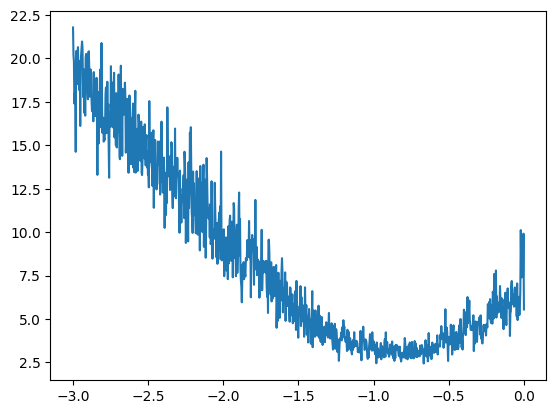

In [186]:
# this is showing the exponent of the learning rate on the x-axis
plt.plot(lri, lossi)

In [130]:
# because we have ~3200 parameters and only 32 examples, we are overfitting the data
# so go back and use all the words, not just first 5

In [115]:
# Now each iteration is doing forward, backward, and update on all inputs
# standard practice is to bath data and do smaller fwd, back, upd passes on different batches

In [117]:
# create integers that index into our dataset
# so each time this is called in the loop, we will get a new batch of 32 indices to use as our batch
torch.randint(0, X.shape[0], (32,))

tensor([139747, 162835, 206851, 210553, 167227,  32507,  61418, 215950, 166518,
         80017,  62247, 191046, 124598, 167583, 139201,   9674, 142902,  72847,
         62108, 115367,  31446,   8740, 127842,  91679,  87169,  35288, 157102,
         60828, 224282, 157732,   1064, 134035])

In [127]:
# much better to have an approximate gradient (as we do when using the minibatch)
# and take more steps
# than it is to evaluate the exact gradient, with fewer steps

In [200]:
# Loss for the whole dataset:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3352, grad_fn=<NllLossBackward0>)

In [142]:
# -0.1 in the update step is a guess
# are we stepping too fast or too slow?
# how do you determine the learning rate?
# how do we get confidence we are stepping at the right speed?
# one way to do this:
# 1. reset parameters
# 2. print loss @ each step, use very low ~0.0001 update rate
# 2.A retry w/ update rate 0.001
# - see that the loss decrease is very slow
# 3. reset params again
# 4. use large rate, 1 or 10
# - in this case 1 made the loss slightly unstable, increaseing/decreasing in big jumps, 10 was worse
# 5. create torch.linspace(0.001, 1, 1000) - 1000 steps between those 2 values
# - recreate as learning rate exponents (-3, 0, 1000) that is 10**-3, 10**0
# 6. set loop for 1000 steps, use learning rate[i]
# 7. track stats learning rate and associated loss
# 8. plot learning rate exponent to learning rate
# use the learing rate, in this case 0.1
# once plateau, learing rate decay - decrease by factor of 10 to 0.01, run again

In [201]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training split - train the parameters
# validation - train the hyperparameters
# test split - performance of the model at the end